In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
import math
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Data Loading

In [2]:
# Load loan-level MBS data
df = pd.read_csv(r'C:\Users\adpur\Desktop\MBS Project\final_cph_data.csv')
df1 = pd.DataFrame(df)
df1.head()

,Loan_ID,Credit Score,First Payment Date,Maturity Date,Occupancy Status,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV)
0,F14Q10000011,794,201403,202902,I,73,45,62000,180,201402,62000.0,0,0,4.25,NaN
1,F14Q10000011,794,201403,202902,I,73,45,62000,180,201403,62000.0,0,1,4.25,NaN
2,F14Q10000011,794,201403,202902,I,73,45,62000,180,201404,62000.0,0,2,4.25,NaN
3,F14Q10000011,794,201403,202902,I,73,45,62000,180,201405,61000.0,0,3,4.25,NaN
4,F14Q10000011,794,201403,202902,I,73,45,62000,180,201406,61000.0,0,4,4.25,NaN


# Exploratory Data Analysis and Preprocessing

In [3]:
df1.shape

(23248344, 15)

In [4]:
single_loan_df = df1[df1['Loan_ID'] == 'F14Q10000011']
single_loan_df

,Loan_ID,Credit Score,First Payment Date,Maturity Date,Occupancy Status,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV)
0,F14Q10000011,794,201403,202902,I,73,45,62000,180,201402,62000.00,0,0,4.25,NaN
1,F14Q10000011,794,201403,202902,I,73,45,62000,180,201403,62000.00,0,1,4.25,NaN
2,F14Q10000011,794,201403,202902,I,73,45,62000,180,201404,62000.00,0,2,4.25,NaN
3,F14Q10000011,794,201403,202902,I,73,45,62000,180,201405,61000.00,0,3,4.25,NaN
4,F14Q10000011,794,201403,202902,I,73,45,62000,180,201406,61000.00,0,4,4.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,F14Q10000011,794,201403,202902,I,73,45,62000,180,202002,19813.88,0,72,4.25,17.0
73,F14Q10000011,794,201403,202902,I,73,45,62000,180,202003,13417.64,0,73,4.25,11.0
74,F14Q10000011,794,201403,202902,I,73,45,62000,180,202004,12998.75,0,74,4.25,10.0
75,F14Q10000011,794,201403,202902,I,73,45,62000,180,202005,12578.38,0,75,4.25,10.0


In [5]:
df1.describe()

,Credit Score,First Payment Date,Maturity Date,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV)
count,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.050245e+07
mean,7.500549e+02,2.017938e+05,2.044527e+05,7.393260e+01,8.603832e+01,2.378500e+05,3.199884e+02,2.020517e+05,2.157762e+05,3.164580e+01,4.143918e+00,1.322874e+02
std,1.306070e+02,2.854700e+02,7.047455e+02,1.870822e+01,2.168078e+02,1.344903e+05,7.309492e+01,2.812477e+02,1.334747e+05,2.662339e+01,1.014367e+00,2.599507e+02
min,3.000000e+02,2.014020e+05,2.022030e+05,3.000000e+00,1.000000e+00,1.000000e+04,8.500000e+01,2.014020e+05,0.000000e+00,0.000000e+00,2.500000e-01,1.000000e+00
25%,7.160000e+02,2.015120e+05,2.044030e+05,6.400000e+01,2.800000e+01,1.370000e+05,3.600000e+02,2.018100e+05,1.174842e+05,1.100000e+01,3.500000e+00,4.100000e+01
50%,7.570000e+02,2.017110e+05,2.046090e+05,7.900000e+01,3.700000e+01,2.090000e+05,3.600000e+02,2.021010e+05,1.886161e+05,2.500000e+01,4.000000e+00,5.800000e+01
75%,7.870000e+02,2.020100e+05,2.050010e+05,8.600000e+01,4.300000e+01,3.120000e+05,3.600000e+02,2.023060e+05,2.888938e+05,4.600000e+01,4.625000e+00,7.500000e+01
max,9.999000e+03,2.025040e+05,2.055030e+05,9.990000e+02,9.990000e+02,2.100000e+06,3.660000e+02,2.025030e+05,2.100000e+06,1.340000e+02,9.250000e+00,9.990000e+02


In [6]:
df1.isna().sum()

Loan_ID                                         0
Credit Score                                    0
First Payment Date                              0
Maturity Date                                   0
Occupancy Status                                0
Original Combined Loan-to-Value (CLTV)          0
Original Debt-to-Income (DTI) Ratio             0
Original UPB                                    0
Original Loan Term                              0
Monthly Reporting Period                        0
Current Actual UPB                              0
Current Loan Delinquency Status                 0
Loan Age                                        0
Current Interest Rate                           0
Estimated Loan-to-Value (ELTV)            2745896
dtype: int64

# Imputation of missing values of ELTV using LOCF
The most appropriate and robust method for imputing missing values in the time-varying Estimated Loan-to-Value (ELTV) column is Last Observation Carried Forward (LOCF), applied within each loan's time series. This assumes that the property's equity position does not change significantly between reporting periods, which is a safer assumption than using a portfolio-wide average (like the median).

In [7]:
# 1. Ensure the data is sorted by loan ID and date (CRITICAL for LOCF)
df2 = df1.sort_values(by=['Loan_ID', 'Monthly Reporting Period'])

# 2. Group the data by Loan ID and fill missing values forward (ffill) within that group
df2['Estimated Loan-to-Value (ELTV)'] = df2.groupby('Loan_ID')['Estimated Loan-to-Value (ELTV)'].fillna(method='ffill')

# 3. Handle any initial NaNs (where no previous observation existed for that loan)
# These are loans with missing ELTV right from Month 1. We fill these with the median CLTV/LTV.
# We will use the portfolio-wide median LTV/CLTV as a reasonable starting anchor.
median_cltv = df2['Original Combined Loan-to-Value (CLTV)'].median()
df2['Estimated Loan-to-Value (ELTV)'].fillna(median_cltv, inplace=True)

print("ELTV missing values successfully imputed using LOCF and anchored by median CLTV.")

ELTV missing values successfully imputed using LOCF and anchored by median CLTV.


In [8]:
df2.isna().sum()

Loan_ID                                   0
Credit Score                              0
First Payment Date                        0
Maturity Date                             0
Occupancy Status                          0
Original Combined Loan-to-Value (CLTV)    0
Original Debt-to-Income (DTI) Ratio       0
Original UPB                              0
Original Loan Term                        0
Monthly Reporting Period                  0
Current Actual UPB                        0
Current Loan Delinquency Status           0
Loan Age                                  0
Current Interest Rate                     0
Estimated Loan-to-Value (ELTV)            0
dtype: int64

# Convert date columns to datetime objects

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 15 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   Loan_ID                                 object 
 1   Credit Score                            int64  
 2   First Payment Date                      int64  
 3   Maturity Date                           int64  
 4   Occupancy Status                        object 
 5   Original Combined Loan-to-Value (CLTV)  int64  
 6   Original Debt-to-Income (DTI) Ratio     int64  
 7   Original UPB                            int64  
 8   Original Loan Term                      int64  
 9   Monthly Reporting Period                int64  
 10  Current Actual UPB                      float64
 11  Current Loan Delinquency Status         object 
 12  Loan Age                                int64  
 13  Current Interest Rate                   float64
 14  Estimated Loan-to-Value (ELTV)  

In [10]:
date_cols = ['Monthly Reporting Period', 'First Payment Date', 'Maturity Date']
for col in date_cols:
    df2[col] = pd.to_datetime(
        df2[col], 
        # Remove the 'format' argument and use infer_datetime_format=True
        infer_datetime_format=True, 
        errors='coerce'
    )

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 15 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Loan_ID                                 object        
 1   Credit Score                            int64         
 2   First Payment Date                      datetime64[ns]
 3   Maturity Date                           datetime64[ns]
 4   Occupancy Status                        object        
 5   Original Combined Loan-to-Value (CLTV)  int64         
 6   Original Debt-to-Income (DTI) Ratio     int64         
 7   Original UPB                            int64         
 8   Original Loan Term                      int64         
 9   Monthly Reporting Period                datetime64[ns]
 10  Current Actual UPB                      float64       
 11  Current Loan Delinquency Status         object        
 12  Loan Age                                

# Encoding Categorical Variables

Occupancy Status

In [11]:
print(df2['Occupancy Status'].value_counts()) 
# do One Hot Encoding - logic: cardinal categories
# P-pending. I-investment. S-second home

Occupancy Status
P    20503169
I     1905928
S      839247
Name: count, dtype: int64


In [12]:
# 1. Create ALL dummy variables (including P, I, and S)
df2_temp = pd.get_dummies(
    df2, 
    columns=['Occupancy Status'], 
    prefix='Occ'
)

# 2. Identify the column for the safest category ('P')
# Assuming the resulting column is named 'Occ_P'
BASELINE_COLUMN = 'Occ_P'

# 3. Drop the baseline column and assign the result back to df3
if BASELINE_COLUMN in df2_temp.columns:
    df2 = df2_temp.drop(BASELINE_COLUMN, axis=1)
    
else:
    print(f"Error: Could not find the expected baseline column '{BASELINE_COLUMN}'. Check original categories.")

df2['Occ_I'] = df2['Occ_I'].astype(int)
df2['Occ_S'] = df2['Occ_S'].astype(int)

print("Dummy variables successfully converted to 1s and 0s.")
print(df2[['Occ_I', 'Occ_S']].head())

Dummy variables successfully converted to 1s and 0s.
   Occ_I  Occ_S
0      1      0
1      1      0
2      1      0
3      1      0
4      1      0


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 16 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Loan_ID                                 object        
 1   Credit Score                            int64         
 2   First Payment Date                      datetime64[ns]
 3   Maturity Date                           datetime64[ns]
 4   Original Combined Loan-to-Value (CLTV)  int64         
 5   Original Debt-to-Income (DTI) Ratio     int64         
 6   Original UPB                            int64         
 7   Original Loan Term                      int64         
 8   Monthly Reporting Period                datetime64[ns]
 9   Current Actual UPB                      float64       
 10  Current Loan Delinquency Status         object        
 11  Loan Age                                int64         
 12  Current Interest Rate                   

# Numerical Variables

continuous_covariate_distributions.png


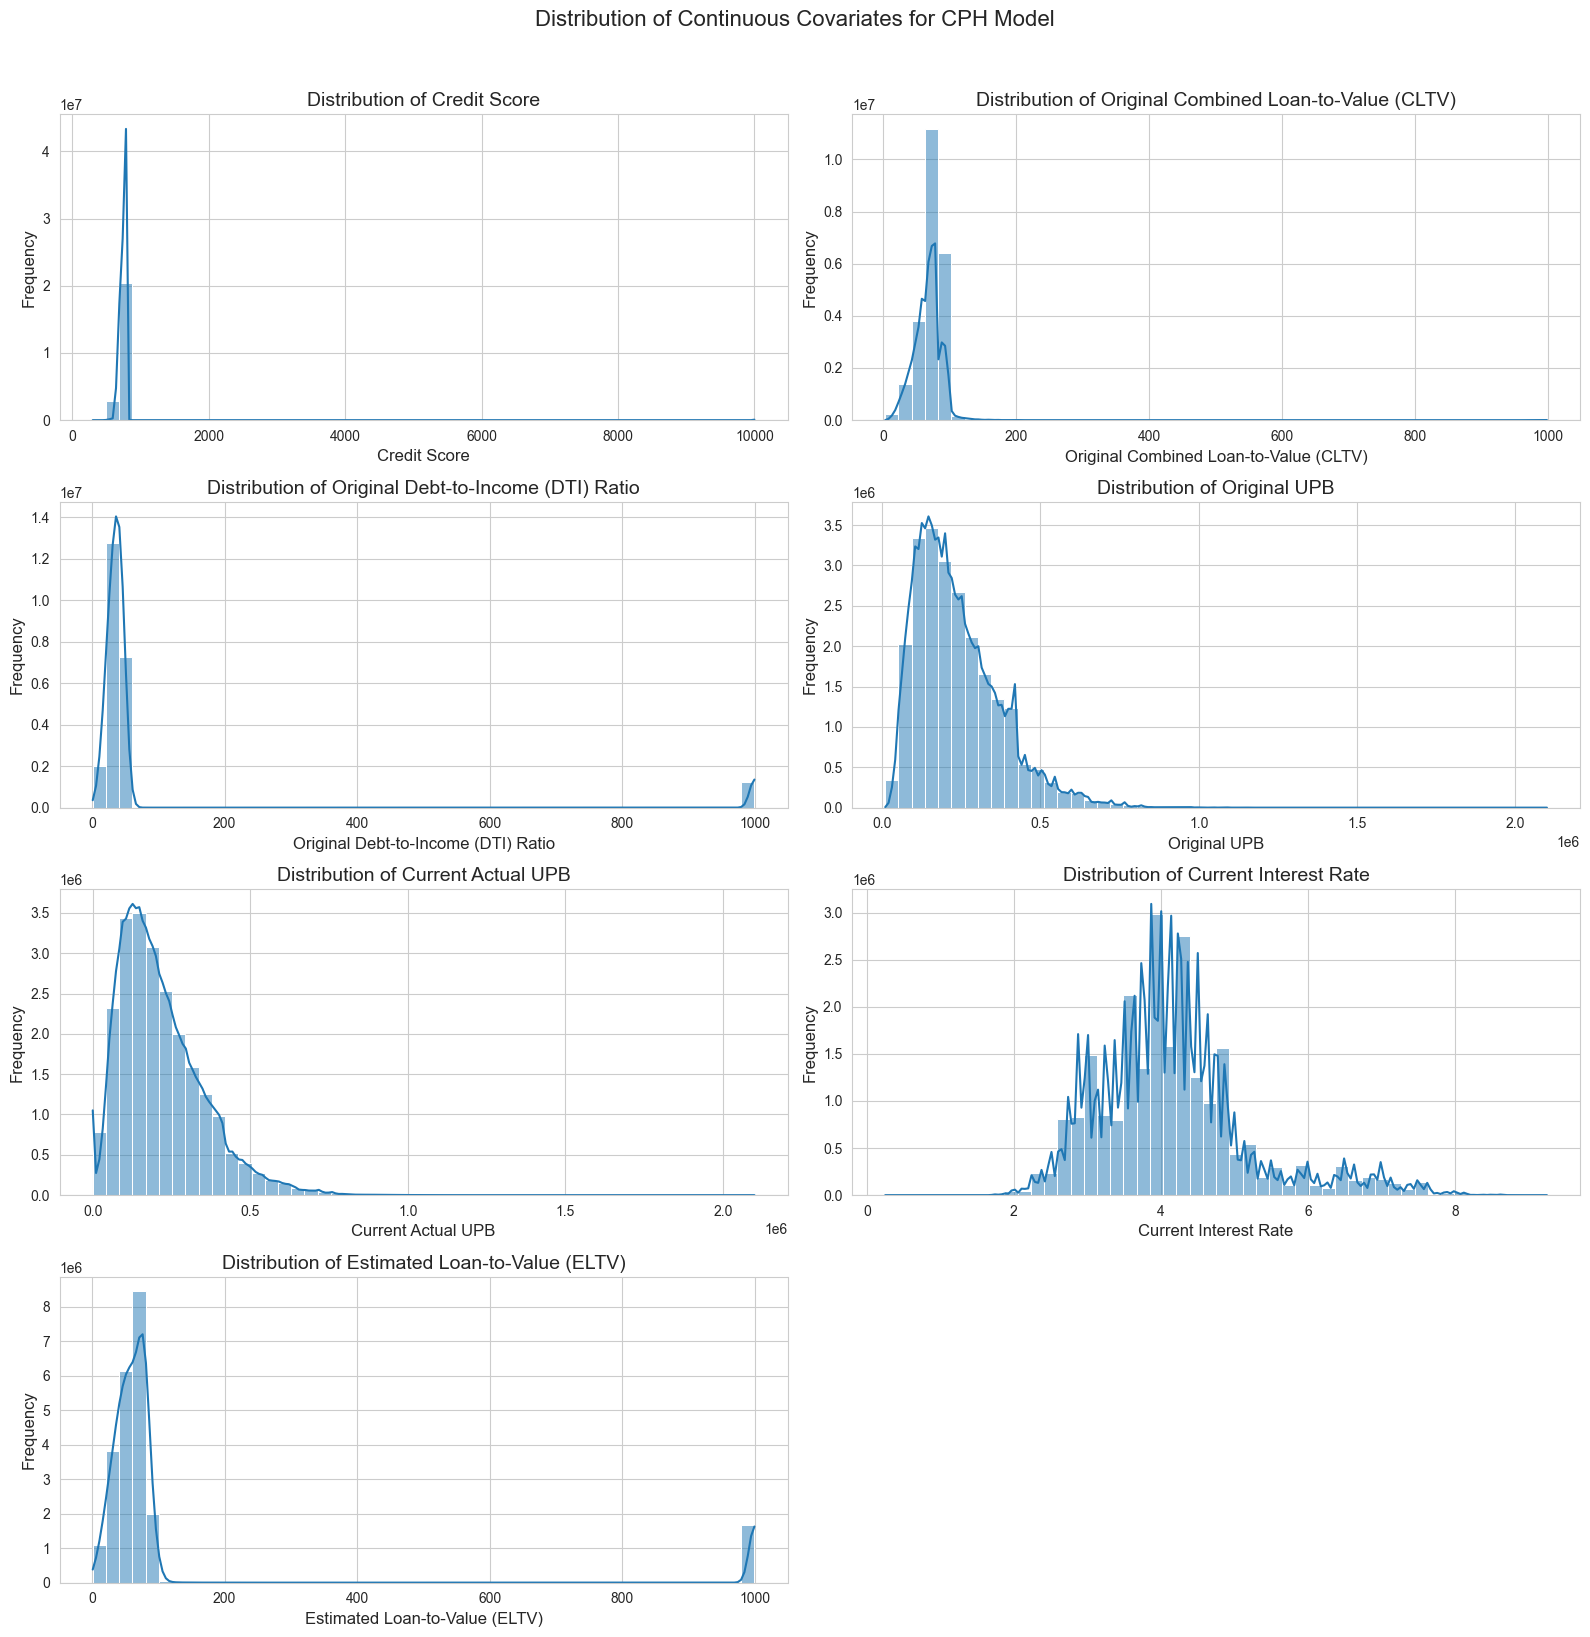

In [14]:
continuous_cols = [
    'Credit Score',
    'Original Combined Loan-to-Value (CLTV)',
    'Original Debt-to-Income (DTI) Ratio',
    'Original UPB',
    'Current Actual UPB',
    'Current Interest Rate',
    'Estimated Loan-to-Value (ELTV)'
]

# Set up the plotting environment
sns.set_style("whitegrid")
# Create a 4x2 grid for the 7 variables
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten() 

# Iterate over the columns and plot the distribution (histogram with KDE)
for i, col in enumerate(continuous_cols):
    ax = axes[i]
    # Use seaborn to plot the distribution with a kernel density estimate
    sns.histplot(df2[col].dropna(), kde=True, ax=ax, bins=50)
    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    
# Hide the unused subplot
fig.delaxes(axes[7])

plt.suptitle('Distribution of Continuous Covariates for CPH Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('continuous_covariate_distributions.png')
print("continuous_covariate_distributions.png")

In [15]:
df3 = df2.copy()

In [16]:
# Apply log1p to handle skewness in balance columns
df3['Original_UPB_Log'] = np.log1p(df3['Original UPB'])
df3['Current_Actual_UPB_Log'] = np.log1p(df3['Current Actual UPB'])

# Scaling numerical variables

In [17]:
# Define the final list of columns to be scaled (including log-transformed UPB)
cols_to_scale = [
    'Credit Score',
    'Original Combined Loan-to-Value (CLTV)',
    'Original Debt-to-Income (DTI) Ratio',
    'Current Interest Rate',
    'Estimated Loan-to-Value (ELTV)',
    'Original_UPB_Log', # Use the log-transformed column
    'Current_Actual_UPB_Log' # Use the log-transformed column
]

scaler = StandardScaler()

# Fit and transform the data
df3[cols_to_scale] = scaler.fit_transform(df3[cols_to_scale])

print("All continuous covariates are now ready for the CPH model.")

All continuous covariates are now ready for the CPH model.


In [18]:
df3.head()

,Loan_ID,Credit Score,First Payment Date,Maturity Date,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV),Occ_I,Occ_S,Original_UPB_Log,Current_Actual_UPB_Log
0,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201402,62000.0,0,0,0.10458,-0.192028,1,0,-2.012606,-0.642479
1,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201403,62000.0,0,1,0.10458,-0.192028,1,0,-2.012606,-0.642479
2,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201404,62000.0,0,2,0.10458,-0.192028,1,0,-2.012606,-0.642479
3,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201405,61000.0,0,3,0.10458,-0.192028,1,0,-2.012606,-0.653748
4,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201406,61000.0,0,4,0.10458,-0.192028,1,0,-2.012606,-0.653748


Current Loan Deliquency Status

In [19]:
print(df3['Current Loan Delinquency Status'].value_counts()) 

Current Loan Delinquency Status
0     11651409
0     11199531
1        92810
1        84392
2        26428
        ...   
77           1
78           1
79           1
80           1
67           1
Name: count, Length: 150, dtype: int64


In [20]:
def map_delinquency_to_ordinal_tv_cov(status):
    """
    Converts delinquency status to an ordinal numeric value for use as a CPH predictor.
    The value increases with risk severity.
    """
    status_str = str(status).strip()
    
    # 1. Handle Termination Codes (Severe Distress)
    if status_str in ['RA', 'RF', 'RE', '999']: # REO Acquisition, Foreclosure, Unknown
        return 3 # Treat as maximum distress level for TVC
    
    # 2. Handle Numeric DPD Codes
    try:
        days_late_code = int(status_str)
        
        if days_late_code >= 3:
            return 3 # Cap at 90+ DPD to represent the failure state (3 = 90 DPD, 4 = 120 DPD, etc.)
        else:
            return days_late_code # Returns 0, 1, or 2
            
    except ValueError:
        # Catch other non-numeric non-delinquent codes (e.g., Repayment Plans, etc.)
        return 0 

# Apply the mapping to the column
df4 = df3.copy()
df4['Delinq_Ordinal_TVC'] = df3['Current Loan Delinquency Status'].apply(map_delinquency_to_ordinal_tv_cov)

print("Created 'Delinq_Ordinal_TVC' column for use as a time-varying covariate.")

Created 'Delinq_Ordinal_TVC' column for use as a time-varying covariate.


In [21]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 19 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Loan_ID                                 object        
 1   Credit Score                            float64       
 2   First Payment Date                      datetime64[ns]
 3   Maturity Date                           datetime64[ns]
 4   Original Combined Loan-to-Value (CLTV)  float64       
 5   Original Debt-to-Income (DTI) Ratio     float64       
 6   Original UPB                            int64         
 7   Original Loan Term                      int64         
 8   Monthly Reporting Period                datetime64[ns]
 9   Current Actual UPB                      float64       
 10  Current Loan Delinquency Status         object        
 11  Loan Age                                int64         
 12  Current Interest Rate                   

In [22]:
# Survival Target Aggregation (T and Delta) 

# Group the monthly history to find the final status and duration for each loan.
survival_df = df4.groupby('Loan_ID').agg(
    
    # --- SURVIVAL MARKERS ---
    Duration_T=('Loan Age', 'last'),
    Event_Delta=('Delinq_Ordinal_TVC', lambda x: 1 if x.max() >= 3 else 0),
    
    # --- TIME-FIXED COVARIATES (Use 'first' record, as they shouldn't change) ---
    FICO_Score=('Credit Score', 'first'),
    Original_CLTV=('Original Combined Loan-to-Value (CLTV)', 'first'),
    Original_DTI=('Original Debt-to-Income (DTI) Ratio', 'first'),
    Original_UPB=('Original UPB', 'first'),
    Original_Term=('Original Loan Term', 'first'),
    Occ_I=('Occ_I', 'first'), # Binary dummies are fixed
    Occ_S=('Occ_S', 'first'), # Binary dummies are fixed
    
    # --- TIME-VARYING (TVC) / LAST-OBSERVED COVARIATES (Use 'last') ---
    # Captures the final risk state before termination or study end.
    Delinq_Status_Last=('Delinq_Ordinal_TVC', 'last'),
    ELTV_Last=('Estimated Loan-to-Value (ELTV)', 'last'),
    Current_Rate_Last=('Current Interest Rate', 'last'),
    Current_UPB_Last=('Current Actual UPB', 'last'),
    
).reset_index()


# --- 2. Verification ---
print("Final survival dataset successfully structured.")
print(f"Total Observations: {len(survival_df):,}")
print("--- Sample of Final Survival Data ---")
print(survival_df[[
    'Loan_ID', 'Duration_T', 'Event_Delta', 'FICO_Score', 'ELTV_Last', 'Current_UPB_Last'
]].head())

Final survival dataset successfully structured.
Total Observations: 550,000
--- Sample of Final Survival Data ---
        Loan_ID  Duration_T  Event_Delta  FICO_Score  ELTV_Last  \
0  F14Q10000011          76            0    0.336469   3.567341   
1  F14Q10000028         131            0   -0.076986  -0.408601   
2  F14Q10000037          77            0   -0.857955   3.567341   
3  F14Q10000049         132            0    0.275216  -0.494412   
4  F14Q10000123         133            0   -0.138238  -0.420860   

   Current_UPB_Last  
0              0.00  
1         191249.92  
2              0.00  
3          36190.15  
4         126284.37  


In [23]:
survival_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Loan_ID             550000 non-null  object 
 1   Duration_T          550000 non-null  int64  
 2   Event_Delta         550000 non-null  int64  
 3   FICO_Score          550000 non-null  float64
 4   Original_CLTV       550000 non-null  float64
 5   Original_DTI        550000 non-null  float64
 6   Original_UPB        550000 non-null  int64  
 7   Original_Term       550000 non-null  int64  
 8   Occ_I               550000 non-null  int64  
 9   Occ_S               550000 non-null  int64  
 10  Delinq_Status_Last  550000 non-null  int64  
 11  ELTV_Last           550000 non-null  float64
 12  Current_Rate_Last   550000 non-null  float64
 13  Current_UPB_Last    550000 non-null  float64
dtypes: float64(6), int64(7), object(1)
memory usage: 58.7+ MB


# Multicollinearity check

In [24]:
covariates = ['Current Loan Delinquency Status', 'Loan Age', 'Estimated Loan-to-Value (ELTV)','Current Interest Rate','Credit Score','Original Debt-to-Income (DTI) Ratio','Occupancy Status','Original Combined Loan-to-Value (CLTV)']

In [25]:
# --- 1. Define ALL Predictor Covariates ---
covariates0 = [
    # Time-Fixed (Origination) Covariates
    'FICO_Score',
    'Original_CLTV',
    'Original_DTI',
    'Original_UPB',
    'Original_Term',
    
    # Binary/Categorical Covariates (Encoded)
    'Occ_I', # Investment Property
    'Occ_S', # Second Home
    
    # Time-Varying (Last Observed) Covariates
    'Delinq_Status_Last',    # Ordinal delinquency status
    'ELTV_Last',             # Estimated LTV
    'Current_Rate_Last',     # Current Interest Rate
    'Current_UPB_Last'       # Current Actual UPB
]

# --- 2. Prepare Data for VIF Check ---
# VIF is sensitive to NaNs, though your data is largely clean after imputation/aggregation.
# VIF requires all input columns to be float or integer (which they are after aggregation).
X0 = survival_df[covariates0].copy().dropna()

# --- 3. Check VIF for each covariate ---
vif_data0 = pd.DataFrame()
vif_data0["Feature"] = X0.columns
vif_data0["VIF"] = [
    variance_inflation_factor(X0.values, i) 
    for i in range(len(X0.columns))
]

print("--- Multicollinearity Check (VIF) on Predictors ---")
print("NOTE: VIF is sensitive to high correlation. Values > 5 or 10 may indicate issues.")
print(vif_data0.sort_values(by="VIF", ascending=False))

--- Multicollinearity Check (VIF) on Predictors ---
NOTE: VIF is sensitive to high correlation. Values > 5 or 10 may indicate issues.
               Feature       VIF
3         Original_UPB  7.666046
4        Original_Term  5.443184
10    Current_UPB_Last  4.486426
8            ELTV_Last  2.672280
9    Current_Rate_Last  1.267725
5                Occ_I  1.128092
2         Original_DTI  1.046362
1        Original_CLTV  1.043513
6                Occ_S  1.040076
7   Delinq_Status_Last  1.017008
0           FICO_Score  1.004985


predictor_correlation_heatmap.png


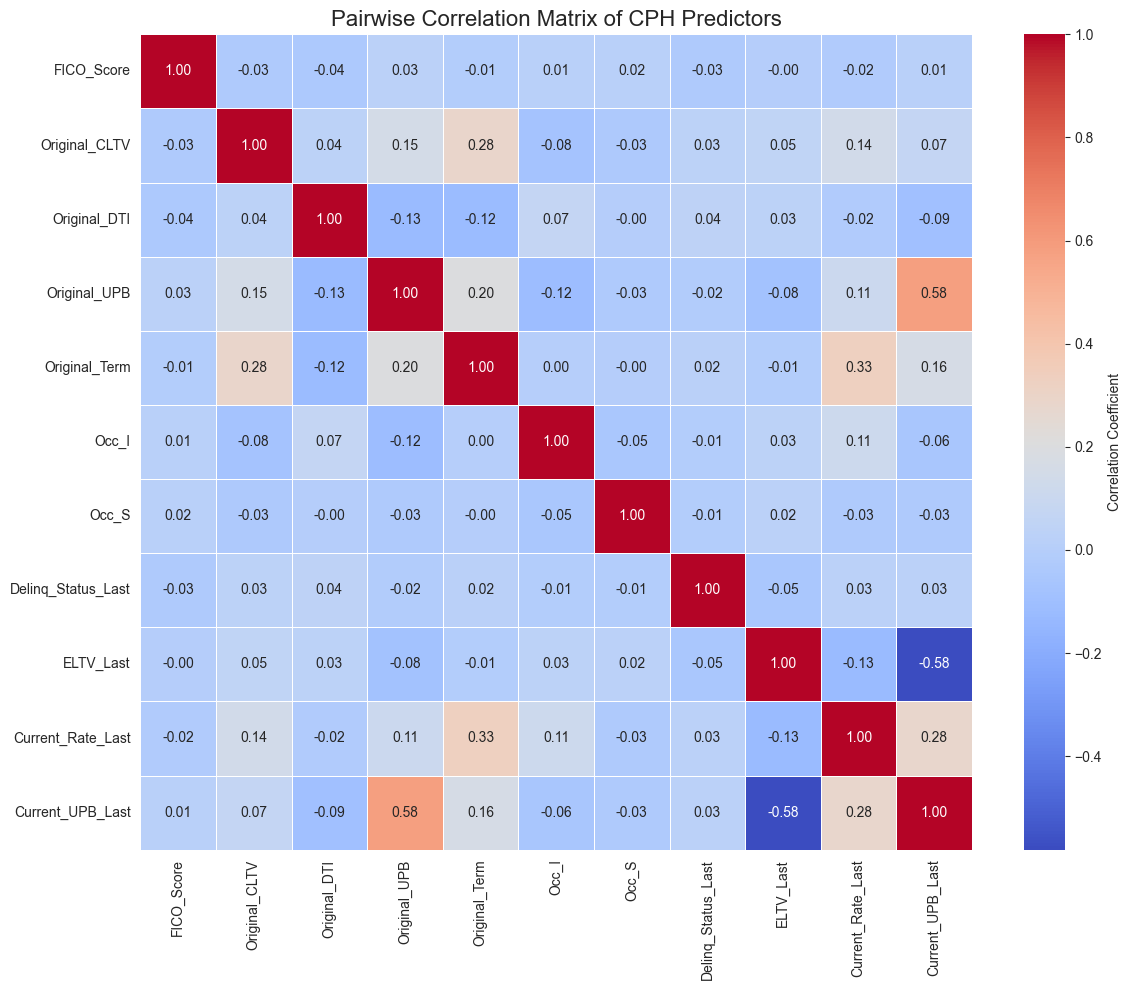

In [26]:
cormat = X0.corr()

# --- 2. Plot the Heatmap (Correction 2: Use sns.heatmap instead of sns.plot) ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    cormat,
    annot=True,              # Display the correlation values on the heatmap
    fmt=".2f",               # Format the numbers to two decimal places
    cmap="coolwarm",         # A good diverging color map for correlation
    linewidths=0.5,          # Lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Pairwise Correlation Matrix of CPH Predictors', fontsize=16)
plt.tight_layout()

# Save the plot
plt.savefig('predictor_correlation_heatmap.png')
print("predictor_correlation_heatmap.png")

In [27]:
cormat

,FICO_Score,Original_CLTV,Original_DTI,Original_UPB,Original_Term,Occ_I,Occ_S,Delinq_Status_Last,ELTV_Last,Current_Rate_Last,Current_UPB_Last
FICO_Score,1.000000,-0.027426,-0.038753,0.027371,-0.009748,0.013621,0.016491,-0.029048,-0.003752,-0.024809,0.014498
Original_CLTV,-0.027426,1.000000,0.036184,0.148655,0.284573,-0.079521,-0.033124,0.032779,0.050367,0.139834,0.070172
Original_DTI,-0.038753,0.036184,1.000000,-0.126165,-0.123885,0.072250,-0.004178,0.039962,0.034318,-0.020566,-0.093904
Original_UPB,0.027371,0.148655,-0.126165,1.000000,0.197162,-0.117060,-0.027506,-0.017388,-0.081118,0.109668,0.580904
Original_Term,-0.009748,0.284573,-0.123885,0.197162,1.000000,0.003481,-0.002476,0.018706,-0.010165,0.330551,0.163371
Occ_I,0.013621,-0.079521,0.072250,-0.117060,0.003481,1.000000,-0.052699,-0.007319,0.030658,0.113016,-0.059018
Occ_S,0.016491,-0.033124,-0.004178,-0.027506,-0.002476,-0.052699,1.000000,-0.009769,0.024293,-0.026868,-0.029481
Delinq_Status_Last,-0.029048,0.032779,0.039962,-0.017388,0.018706,-0.007319,-0.009769,1.000000,-0.053593,0.025147,0.026876
ELTV_Last,-0.003752,0.050367,0.034318,-0.081118,-0.010165,0.030658,0.024293,-0.053593,1.000000,-0.129367,-0.581191
Current_Rate_Last,-0.024809,0.139834,-0.020566,0.109668,0.330551,0.113016,-0.026868,0.025147,-0.129367,1.000000,0.278620


In [28]:
survival_df.head()

,Loan_ID,Duration_T,Event_Delta,FICO_Score,Original_CLTV,Original_DTI,Original_UPB,Original_Term,Occ_I,Occ_S,Delinq_Status_Last,ELTV_Last,Current_Rate_Last,Current_UPB_Last
0,F14Q10000011,76,0,0.336469,-0.049850,-0.189284,62000,180,1,0,0,3.567341,0.104580,0.00
1,F14Q10000028,131,0,-0.076986,0.431222,-0.216959,262000,360,0,0,0,-0.408601,0.227809,191249.92
2,F14Q10000037,77,0,-0.857955,-0.958541,-0.221571,247000,240,0,0,0,3.567341,0.597498,0.00
3,F14Q10000049,132,0,0.275216,-2.134495,-0.226183,200000,180,0,0,0,-0.494412,-0.634797,36190.15
4,F14Q10000123,133,0,-0.138238,-0.370564,-0.309206,170000,360,0,0,0,-0.420860,-0.018650,126284.37


# Sacling Continuous Columns in Surviva DF

In [29]:
# Create a copy of the final aggregated DataFrame to work with
survival_df1 = survival_df.copy()

# --- 1. Apply Log Transformation to UPB (Mandatory for Skewness) ---
# This step addresses the structural skewness of loan balance.
survival_df1['Current_UPB_Log_ZScore'] = np.log1p(survival_df1['Current_UPB_Last'])

# --- 2. Define the full list of columns to be Z-Scored ---
SCALING_COLS = [
    'FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Term',
    'Current_Rate_Last', 'ELTV_Last', 
    'Current_UPB_Log_ZScore'
]

# --- 3. Apply Standard Scaling (Z-Score) ---
scaler = StandardScaler()

# Fit and transform the continuous columns in place
survival_df1[SCALING_COLS] = scaler.fit_transform(survival_df1[SCALING_COLS])

print("All continuous covariates are now successfully scaled and ready for CPH fitting.")

All continuous covariates are now successfully scaled and ready for CPH fitting.


In [30]:
survival_df1.head()

,Loan_ID,Duration_T,Event_Delta,FICO_Score,Original_CLTV,Original_DTI,Original_UPB,Original_Term,Occ_I,Occ_S,Delinq_Status_Last,ELTV_Last,Current_Rate_Last,Current_UPB_Last,Current_UPB_Log_ZScore
0,F14Q10000011,76,0,0.298057,-0.073575,-0.115003,62000,-2.222840,1,0,0,1.152216,-0.214810,0.00,-1.036681
1,F14Q10000028,131,0,-0.078006,0.417387,-0.151722,262000,0.472693,0,0,0,-0.926777,-0.120854,191249.92,0.952914
2,F14Q10000037,77,0,-0.788345,-1.000948,-0.157842,247000,-1.324329,0,0,0,1.152216,0.161013,0.00,-1.036681
3,F14Q10000049,132,0,0.242344,-2.201078,-0.163961,200000,-2.222840,0,0,0,-0.971647,-0.778545,36190.15,0.680558
4,F14Q10000123,133,0,-0.133718,-0.400883,-0.274119,170000,0.472693,0,0,0,-0.933187,-0.308766,126284.37,0.885013


# Fitting the CPH Model

In [31]:
# === Auto-build survival_df2 (if missing) and fit Cox PH robustly ===
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
from lifelines.utils import concordance_index

# -------------------------------
# 1) Build/locate survival_df2
# -------------------------------
required_cols = {"Duration_T", "Event_Delta"}

def choose_base_df():
    # Prefer common names if they exist and have Duration_T & Event_Delta
    preferred = ["survival_df2_clean", "survival_df2", "survival_df1", "df2", "df1", "df"]
    for nm in preferred:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
            df = globals()[nm]
            if required_cols.issubset(df.columns):
                print(f"✅ Base DataFrame: '{nm}' (has Duration_T & Event_Delta)")
                return df.copy(), nm
    # Otherwise, scan all DataFrames in memory
    best = None
    for nm, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame) and required_cols.issubset(obj.columns):
            best = (obj.copy(), nm)
            break
    if best is None:
        raise NameError(
            "Could not find any DataFrame with Duration_T and Event_Delta.\n"
            "→ Please run the preprocessing cells that create these columns."
        )
    print(f"✅ Base DataFrame: '{best[1]}' (auto-detected)")
    return best

base_df, base_name = choose_base_df()

# If MODEL_COLS exists and is available in base_df, use exactly those; else infer predictors.
if "MODEL_COLS" in globals():
    need = set(MODEL_COLS)
    if need.issubset(base_df.columns):
        survival_df2 = base_df[MODEL_COLS].copy()
        print("✅ Constructed survival_df2 from MODEL_COLS.")
    else:
        missing = sorted(list(need - set(base_df.columns)))
        print(f"ℹ️ MODEL_COLS present, but missing in '{base_name}': {missing}")
        # Fall back to inferred predictors.
        MODEL_COLS = None  # so we infer below

if "survival_df2" not in globals() or not isinstance(survival_df2, pd.DataFrame):
    # Infer predictors: numeric + common engineered columns, prioritize FICO and user covariates if present
    numeric_preds = [c for c in base_df.columns if c not in required_cols and pd.api.types.is_numeric_dtype(base_df[c])]
    # Common engineered/encoded candidates (may be numeric already)
    common_cands = [
        "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Term",
        "Current_Rate_Last", "ELTV_Last", "Current_UPB_Log_ZScore",
        "Occ_I", "Occ_S", "Delinq_Status_Last"
    ]
    # Keep those that actually exist
    common_cands = [c for c in common_cands if c in base_df.columns]
    # Merge with numeric preds, preserving order and uniqueness
    preds = []
    for c in common_cands + numeric_preds:
        if c not in preds:
            preds.append(c)
    # Ensure we have at least one predictor
    if not preds:
        raise ValueError("No predictors found to build survival_df2. Check your preprocessing steps.")
    # Build survival_df2
    survival_df2 = base_df[preds + list(required_cols)].copy()
    print(f"✅ Constructed survival_df2 with inferred predictors ({len(preds)} columns).")
    if "FICO_Score" in survival_df2.columns:
        print("👍 FICO_Score retained.")

# --------------------------------------
# 2) Sanitize to avoid math exceptions
# --------------------------------------
pred_cols = [c for c in survival_df2.columns if c not in required_cols]

# Convert predictors to numeric where needed
for c in pred_cols:
    if survival_df2[c].dtype.kind not in "biufc":
        survival_df2[c] = pd.to_numeric(survival_df2[c], errors="coerce")

# Drop inf/NaN rows in used columns
survival_df2 = survival_df2.replace([np.inf, -np.inf], np.nan)
survival_df2 = survival_df2.dropna(subset=list(required_cols) + pred_cols)

# Ensure binary Event_Delta
survival_df2["Event_Delta"] = (survival_df2["Event_Delta"] > 0).astype(int)

# Remove nonpositive durations
nonpos_mask = survival_df2["Duration_T"] <= 0
if nonpos_mask.any():
    print(f"⚠️ Dropping {nonpos_mask.sum()} rows with non-positive Duration_T.")
    survival_df2 = survival_df2.loc[~nonpos_mask].copy()

# If all durations identical, add tiny jitter to break ties
if survival_df2["Duration_T"].nunique() == 1:
    print("⚠️ All durations identical; adding tiny epsilon jitter.")
    eps = np.linspace(1e-9, 1e-6, len(survival_df2))
    survival_df2["Duration_T"] = survival_df2["Duration_T"] + eps

# Must have at least one event
if (survival_df2["Event_Delta"] == 1).sum() == 0:
    raise ValueError("No events (Event_Delta == 1) present after cleaning. Cannot fit Cox model.")

# -------------------------------------------------
# 3) Fit Cox PH with ridge penalty and retries
# -------------------------------------------------
penalty_grid = [0.1, 0.25, 0.5, 1.0]
cph = None
last_err = None

for p in penalty_grid:
    try:
        cph = CoxPHFitter(penalizer=p, l1_ratio=0.0)  # ridge only
        cph.fit(
            survival_df2,
            duration_col="Duration_T",
            event_col="Event_Delta",
            show_progress=True
        )
        print(f"\n✅ Model converged with penalizer = {p}")
        break
    except ConvergenceError as e:
        last_err = e
        print(f"⚠️ ConvergenceError at penalizer={p}: {e}")
    except ZeroDivisionError as e:
        last_err = e
        print(f"⚠️ ZeroDivisionError at penalizer={p}: {e}")
    except Exception as e:
        last_err = e
        print(f"⚠️ Error at penalizer={p}: {e}")

if cph is None:
    raise last_err

# --------------------------------------
# 4) Summary and concordance
# --------------------------------------
print("\n--- CPH Model Fit Summary ---")
cph.print_summary(model="Mortgage Default Hazard Model (Final Fit)", decimals=4)

risk = -cph.predict_partial_hazard(survival_df2)
ci = concordance_index(survival_df2["Duration_T"], risk, survival_df2["Event_Delta"])
print(f"\nConcordance index (in-sample): {ci:.4f}")

# Optional: proportional hazards assumption check
#cph.check_assumptions(survival_df2, p_value_threshold=0.01, show_plots=False)


✅ Base DataFrame: 'survival_df1' (has Duration_T & Event_Delta)
✅ Constructed survival_df2 with inferred predictors (12 columns).
👍 FICO_Score retained.
⚠️ Dropping 462 rows with non-positive Duration_T.
Iteration 1: norm_delta = 5.27e-01, step_size = 0.9500, log_lik = -217103.04762, newton_decrement = 1.03e+04, seconds_since_start = 0.2
Iteration 2: norm_delta = 2.22e-01, step_size = 0.9500, log_lik = -226147.56190, newton_decrement = 1.65e+04, seconds_since_start = 0.3
Iteration 3: norm_delta = 2.48e-02, step_size = 0.9500, log_lik = -210626.10818, newton_decrement = 1.18e+02, seconds_since_start = 0.4
Iteration 4: norm_delta = 2.56e-03, step_size = 1.0000, log_lik = -210500.79873, newton_decrement = 1.10e+00, seconds_since_start = 0.5
Iteration 5: norm_delta = 2.68e-05, step_size = 1.0000, log_lik = -210499.69058, newton_decrement = 1.18e-04, seconds_since_start = 0.5
Iteration 6: norm_delta = 2.91e-09, step_size = 1.0000, log_lik = -210499.69047, newton_decrement = 1.40e-12, second

model,lifelines.CoxPHFitter
duration col,'Duration_T'
event col,'Event_Delta'
penalizer,0.1
l1 ratio,0.0
baseline estimation,breslow
number of observations,549538
number of events observed,18416
partial log-likelihood,-210499.6905
time fit was run,2025-10-27 02:50:57 UTC
model,Mortgage Default Hazard Model (Final Fit)



Concordance index (in-sample): 0.7623


In [32]:
# === Out-of-sample evaluation for Cox PH (robust & error-free) ===
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

# -------------------------------
# 1) Build/locate dataset
# -------------------------------
required_cols = {"Duration_T", "Event_Delta"}

def choose_base_df():
    preferred = ["survival_df2_clean", "survival_df2", "survival_df1", "df2", "df1", "df"]
    for nm in preferred:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
            df = globals()[nm]
            if required_cols.issubset(df.columns):
                print(f"✅ Base DataFrame: '{nm}'")
                return df.copy()
    # Scan all dataframes if preferred names missing
    for nm, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame) and required_cols.issubset(obj.columns):
            print(f"✅ Base DataFrame (auto-detected): '{nm}'")
            return obj.copy()
    raise NameError(
        "No DataFrame with Duration_T and Event_Delta found. "
        "Please run the preprocessing cells that create them."
    )

base_df = choose_base_df()

# If MODEL_COLS exists and present, use exactly those; else infer predictors.
if "MODEL_COLS" in globals() and set(MODEL_COLS).issubset(base_df.columns):
    work_df = base_df[MODEL_COLS].copy()
    print("✅ Using MODEL_COLS for predictors.")
else:
    # Infer predictors: keep numeric columns (excluding required) and prioritize common engineered covariates
    common = [
        "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Term",
        "Current_Rate_Last", "ELTV_Last", "Current_UPB_Log_ZScore",
        "Occ_I", "Occ_S", "Delinq_Status_Last"
    ]
    common = [c for c in common if c in base_df.columns]
    numeric_preds = [c for c in base_df.columns if c not in required_cols and pd.api.types.is_numeric_dtype(base_df[c])]
    preds = []
    for c in common + numeric_preds:
        if c not in preds:
            preds.append(c)
    if not preds:
        raise ValueError("No predictor columns found to build dataset for Cox model.")
    work_df = base_df[preds + list(required_cols)].copy()
    if "FICO_Score" in work_df.columns:
        print("👍 FICO_Score retained among predictors.")

# -------------------------------
# 2) Sanitize inputs
# -------------------------------
pred_cols = [c for c in work_df.columns if c not in required_cols]

# Ensure numeric predictors
for c in pred_cols:
    if work_df[c].dtype.kind not in "biufc":
        work_df[c] = pd.to_numeric(work_df[c], errors="coerce")

# Clean inf / NaN
work_df = work_df.replace([np.inf, -np.inf], np.nan)
work_df = work_df.dropna(subset=pred_cols + list(required_cols))

# Ensure binary events
work_df["Event_Delta"] = (work_df["Event_Delta"] > 0).astype(int)

# Drop nonpositive durations
nonpos = work_df["Duration_T"] <= 0
if nonpos.any():
    print(f"⚠️ Dropping {nonpos.sum()} rows with non-positive Duration_T.")
    work_df = work_df.loc[~nonpos].copy()

# Ties-only guard: if all durations identical, add tiny jitter
if work_df["Duration_T"].nunique() == 1:
    print("⚠️ All durations identical; adding small jitter.")
    eps = np.linspace(1e-9, 1e-6, len(work_df))
    work_df["Duration_T"] = work_df["Duration_T"] + eps

# Must have at least one event overall
if (work_df["Event_Delta"] == 1).sum() == 0:
    raise ValueError("No events (Event_Delta==1) present after cleaning. Cannot evaluate out-of-sample.")

# -------------------------------
# 3) Train/Test split with validity checks
# -------------------------------
def valid_split(df, test_size=0.30, max_tries=25):
    for seed in range(42, 42 + max_tries):
        tr, te = train_test_split(df, test_size=test_size, random_state=seed, shuffle=True)
        ne_tr = int((tr["Event_Delta"] == 1).sum())
        ne_te = int((te["Event_Delta"] == 1).sum())
        if ne_tr > 0 and ne_te > 0:
            return tr.reset_index(drop=True), te.reset_index(drop=True), seed
    raise ValueError("Could not find a train/test split with events present in BOTH sets. Try different test_size or preprocess.")

train_df, test_df, used_seed = valid_split(work_df, test_size=0.30, max_tries=50)
print(f"🔀 Split seed: {used_seed} | Train n={len(train_df)} (events={int((train_df['Event_Delta']==1).sum())}), "
      f"Test n={len(test_df)} (events={int((test_df['Event_Delta']==1).sum())})")

# -------------------------------
# 4) Fit Cox model (ridge + retries)
# -------------------------------
penalty_grid = [0.1, 0.25, 0.5, 1.0]
cph = None
last_err = None

for p in penalty_grid:
    try:
        cph = CoxPHFitter(penalizer=p, l1_ratio=0.0)  # ridge only
        cph.fit(train_df, duration_col="Duration_T", event_col="Event_Delta", show_progress=True)
        print(f"✅ Train convergence with penalizer={p}")
        break
    except ConvergenceError as e:
        last_err = e
        print(f"⚠️ ConvergenceError at penalizer={p}: {e}")
    except ZeroDivisionError as e:
        last_err = e
        print(f"⚠️ ZeroDivisionError at penalizer={p}: {e}")
    except Exception as e:
        last_err = e
        print(f"⚠️ Error at penalizer={p}: {e}")

if cph is None:
    raise last_err

# -------------------------------
# 5) In-sample vs Out-of-sample C-index
# -------------------------------
# In-sample (train)
train_risk = -cph.predict_partial_hazard(train_df)
ci_train = concordance_index(train_df["Duration_T"], train_risk, train_df["Event_Delta"])

# Out-of-sample (test)
test_risk = -cph.predict_partial_hazard(test_df)
ci_test = concordance_index(test_df["Duration_T"], test_risk, test_df["Event_Delta"])

print("\n--- Concordance Index ---")
print(f"Train (in-sample) C-index: {ci_train:.4f}")
print(f"Test  (out-of-sample) C-index: {ci_test:.4f}")

# Optional: PH assumption check on train
# cph.check_assumptions(train_df, p_value_threshold=0.01, show_plots=False)


✅ Base DataFrame: 'survival_df2'
👍 FICO_Score retained among predictors.
🔀 Split seed: 42 | Train n=384676 (events=12926), Test n=164862 (events=5490)
Iteration 1: norm_delta = 5.27e-01, step_size = 0.9500, log_lik = -147809.84365, newton_decrement = 7.24e+03, seconds_since_start = 0.1
Iteration 2: norm_delta = 2.23e-01, step_size = 0.9500, log_lik = -154127.70289, newton_decrement = 1.16e+04, seconds_since_start = 0.2
Iteration 3: norm_delta = 2.41e-02, step_size = 0.9500, log_lik = -143253.94703, newton_decrement = 7.83e+01, seconds_since_start = 0.2
Iteration 4: norm_delta = 2.40e-03, step_size = 1.0000, log_lik = -143171.21787, newton_decrement = 6.80e-01, seconds_since_start = 0.3
Iteration 5: norm_delta = 2.34e-05, step_size = 1.0000, log_lik = -143170.53354, newton_decrement = 6.34e-05, seconds_since_start = 0.3
Iteration 6: norm_delta = 2.20e-09, step_size = 1.0000, log_lik = -143170.53347, newton_decrement = 5.61e-13, seconds_since_start = 0.4
Convergence success after 6 itera